INFO 2026-06-08 15:55:07,670 93233 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-06-08 15:55:07,678 93233 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-06-08 15:55:07,678 93233 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-06-08 15:55:17,891 93233 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-06-08 15:56:12,056 93233 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-06-08 15:56:12,109 93233 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***


frame loading (image folder) [rank=0]: 100%|██████████████████████████████████████████████| 5/5 [00:00<00:00, 18.02it/s]
INFO 2026-06-08 15:56:12,887 93233 sam3_base_predictor.py: 155: started new session f5e64c31-c84d-489b-90a3-f85f6db0ea8c


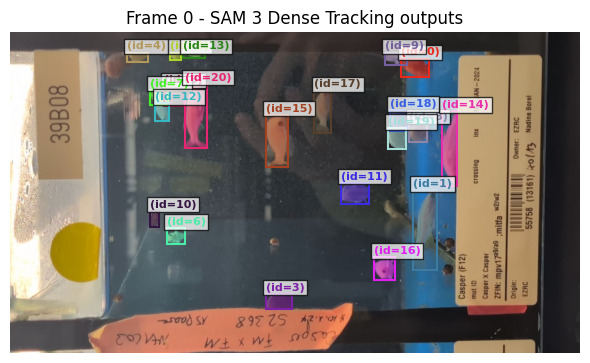

propagate_in_video:   0%|          | 0/5 [00:00<?, ?it/s]

INFO 2026-06-08 16:06:42,345 93233 sam3_base_predictor.py: 314: propagation ended in session f5e64c31-c84d-489b-90a3-f85f6db0ea8c


OutOfMemoryError: CUDA out of memory. Tried to allocate 8.42 GiB. GPU 0 has a total capacity of 8.00 GiB of which 0 bytes is free. Process 710 has 17179869184.00 GiB memory in use. Including non-PyTorch memory, this process has 17179869184.00 GiB memory in use. Of the allocated memory 14.61 GiB is allocated by PyTorch, and 1.51 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [12]:
# %%
import os
import sam3
import torch
from sam3.model_builder import build_sam3_video_predictor
from sam3.visualization_utils import (
    load_frame,
    prepare_masks_for_visualization,
    visualize_formatted_frame_output,
)
import cv2
import matplotlib.pyplot as plt
import numpy as np
import glob

# %%
VIDEO_PATH="./videos/frames"
bpe_path = "./sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz"

# %%
imgs = []
cap = cv2.VideoCapture(VIDEO_PATH)
imgs = []

# %%
def propagate_in_video(predictor, session_id):
    # we will just propagate from frame 0 to the end of the video
    outputs_per_frame = {}
    for response in predictor.handle_stream_request(
        request=dict(
            type="propagate_in_video",
            session_id=session_id,
        )
    ):
        outputs_per_frame[response["frame_index"]] = response["outputs"]

    return outputs_per_frame

# %%
predictor = build_sam3_video_predictor(gpus_to_use=[0], bpe_path=bpe_path)

# %%

video_frames_for_vis = glob.glob(os.path.join(VIDEO_PATH, "*.jpg"))
try:
    # integer sort instead of string sort (so that e.g. "2.jpg" is before "11.jpg")
    video_frames_for_vis.sort(
        key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
    )
except ValueError:
    # fallback to lexicographic sort if the format is not "<frame_index>.jpg"
    print(
        f'frame names are not in "<frame_index>.jpg" format: {video_frames_for_vis[:5]=}, '
        f"falling back to lexicographic sort."
    )
    video_frames_for_vis.sort()

# %%
response = predictor.handle_request(
    request=dict(
        type="start_session",
        resource_path=VIDEO_PATH,
    )
)
session_id = response["session_id"]

# %%
_ = predictor.handle_request(
    request=dict(
        type="reset_session",
        session_id=session_id,
    )
)

prompt_text_str = "Fish"
frame_idx = 0
response = predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=frame_idx,
        text=prompt_text_str,
    )
)
out = response["outputs"]

plt.close("all")
visualize_formatted_frame_output(
    frame_idx,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({frame_idx: out})],
    titles=["SAM 3 Dense Tracking outputs"],
    figsize=(6, 4),
)

# %%
# now we propagate the outputs from frame 0 to the end of the video and collect all outputs
outputs_per_frame = propagate_in_video(predictor, session_id)

# finally, we reformat the outputs for visualization and plot the outputs every 60 frames
outputs_per_frame = prepare_masks_for_visualization(outputs_per_frame)

vis_frame_stride = 50
plt.close("all")
for frame_idx in range(0, len(outputs_per_frame), vis_frame_stride):
    visualize_formatted_frame_output(
        frame_idx,
        video_frames_for_vis,
        outputs_list=[outputs_per_frame],
        titles=["SAM 3 Dense Tracking outputs"],
        figsize=(6, 4),
    )

# %%
outputs_per_frame

# %%
obj_ids = set()
mask = np.zeros((len(video_frames_for_vis), video_frames_for_vis[0].shape[0], video_frames_for_vis[0].shape[1]), dtype=np.uint16)
for frame_idx, mask_objs in outputs_per_frame.items():
    for mask_obj_id, mask_obj in mask_objs.items():
        mask[frame_idx, mask_obj] = mask_obj_id
        obj_ids.add(mask_obj_id)